In [42]:
# Import required libraries
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler # Do NOT standardize features!
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection and setup
def get_device():
    """Detect and return the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    
    print(f"PyTorch version: {torch.__version__}")
    return device

# Set device
device = get_device()


Using MPS (Metal Performance Shaders) device
PyTorch version: 2.8.0


In [43]:
# Configuration
CONFIG = {
    'embedding_dim': 4096,  # D - configurable embedding dimension (will be updated based on JL lemma)
    'hidden_dim': 256,      # Hidden dimension for Q/K projections
    'batch_size': 64,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_epochs': 1,       # Number of epochs
    'num_samples': 12800,     # Total number of augmented samples (different random projections)
    'jl_epsilon': 0.3,      # JL lemma epsilon for distance preservation
    'use_attention_scores': False, # Use attention scores instead of weights
    'consistency_weight': 0.1,  # Weight for batch consistency regularization
    'consistency_type': 'cosine',  # 'cosine' (default, recommended) or 'variance'
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {device}")

Configuration:
  embedding_dim: 4096
  hidden_dim: 256
  batch_size: 64
  learning_rate: 0.001
  num_epochs: 1
  num_samples: 12800
  jl_epsilon: 0.3
  use_attention_scores: False
  consistency_weight: 0.1
  consistency_type: cosine

Device: mps


## 1. Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data from `Single_Cell_TPM_threshold2.csv`. This dataset contains gene expression data for ~13,669 genes across 128 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Perform PCA to reduce dimensionality to D=1024
4. Generate initial (N, D) embedding matrix where N=128 neuron classes


In [44]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)

preferred_path = 'data/transcriptomics/GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = 'data/transcriptomics/GSE136049_genes_by_neurons_counts.csv'

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X_ = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X_ = np.log1p(df.T.values)

neuron_classes = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_classes): {df.shape}")
print(f"Transposed to (neurons x genes): {X_.shape}")
print(f"Neuron classes (sample 10): {neuron_classes[:10]}")
print(f"Genes (sample 10): {transcript_names[:10]}")

# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
X_original = X_
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_classes)
assert N_neurons == X_original.shape[0]
print(f"Number of neuron classes: {N_neurons}")
print(f"Neuron classes: {neuron_classes}")


Loaded: data/transcriptomics/GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_classes): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Genes (sample 10): ['2L52.1a.1', '2L52.2', '2RSSE.1a.1', '2RSSE.5', '2RSSE.7', '3R5.1a.1', '3R5.2', '4R79.1a.1', '4R79.2a.1', 'AC3.10.1']
Without standardization (22469,) genes (first 5) 
	mean: [4.22585203e-03 2.22227906e-05 5.10157551e-02 5.46599387e-04
 8.34766143e-06], 
	std: [1.10494685e-02 1.83119688e-04 5.51118595e-02 2.41040249e-03
 9.48112084e-05]
Number of neuron classes: 130
Neuron classes: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 'AVL', 'AVM', 'AWA', 'AWB', 'AWC_OFF', 'AWC_ON', 'BAG', 'BDU', 'CAN', 'CEP', 'DA', 

In [45]:
# Load single-cell transcriptome data from Single_Cell_TPM_threshold2.csv

df = pd.read_csv('data/transcriptomics/Single_Cell_TPM_threshold2.csv', index_col=0)

# Skip gene metadata columns and get neuron class columns
gene_metadata_cols = ['Gene_Name', 'Sequence_Name', 'Wormbase_ID']
neuron_cols = [col for col in df.columns if col not in gene_metadata_cols]

X_ = df[neuron_cols].values  # genes x neurons
X_ = X_.T  # neurons x genes

# Apply log1p transformation
X_ = np.log1p(X_)

neuron_classes = neuron_cols
transcript_names = df.index.tolist()
print(f"Loaded: Single_Cell_TPM_threshold2.csv")
print(f"Original table shape (genes x neuron_classes): {df.shape}")
print(f"Transposed to (neurons x genes): {X_original.shape}")
print(f"Neuron classes (sample 10): {neuron_classes[:10]}")
print(f"Genes (sample 10): {transcript_names[:10]}")

# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
X_original = X_
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_classes)
assert N_neurons == X_original.shape[0]
print(f"Number of neuron classes: {N_neurons}")
print(f"Neuron classes: {neuron_classes}")


Loaded: Single_Cell_TPM_threshold2.csv
Original table shape (genes x neuron_classes): (13669, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron classes (sample 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Genes (sample 10): ['aap-1', 'aat-1', 'aat-2', 'aat-3', 'aat-4', 'aat-5', 'aat-6', 'aat-9', 'abf-1', 'abf-2']
Without standardization (13669,) genes (first 5) 
	mean: [3.15699809 0.74813485 0.98035184 1.67104122 0.04867513], 
	std: [1.18940597 1.51467677 1.28073488 1.549812   0.5485409 ]
Number of neuron classes: 128
Neuron classes: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 'AVL', 'AVM', 'AWA', 'AWB', 'AWC_OFF', 'AWC_ON', 'BAG', 'BDU', 'CAN', 'CEP', 'DA', 'DA9', 'DB', 'DB01', 'DVA', 'DVB', 'DVC', 'FLP', 'HSN', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'IL1', 'IL2_D

In [46]:
# Load neuron metadata from neuron_master_sheet.csv
neuron_metadata_df = pd.read_csv('data/neuron_master_sheet.csv')

print(f"Loaded neuron metadata: {neuron_metadata_df.shape}")
print(f"Columns: {neuron_metadata_df.columns.tolist()}")
print(f"Sample rows:")
print(neuron_metadata_df.head())

# Create lookup dictionaries: label -> metadata and class -> metadata
label_to_neurotransmitter = dict(zip(neuron_metadata_df['label'], neuron_metadata_df['neurotransmitter']))
label_to_type = dict(zip(neuron_metadata_df['label'], neuron_metadata_df['type']))

class_to_neurotransmitter = dict(zip(neuron_metadata_df['class'], neuron_metadata_df['neurotransmitter']))
class_to_type = dict(zip(neuron_metadata_df['class'], neuron_metadata_df['type']))

print(f"\nLookup dictionaries created:")
print(f"  label_to_neurotransmitter: {len(label_to_neurotransmitter)} entries")
print(f"  class_to_neurotransmitter: {len(class_to_neurotransmitter)} entries")
print(f"  label_to_type: {len(label_to_type)} entries")
print(f"  class_to_type: {len(class_to_type)} entries")


Loaded neuron metadata: (300, 7)
Columns: ['label', 'class', 'neurotransmitter', 'type', 'x', 'y', 'z']
Sample rows:
  label class neurotransmitter     type     x      y      z
0  ADAL   ADA              Glu    inter  0.03  94.34  10.31
1  ADAR   ADA              Glu    inter -1.43  91.22 -11.64
2  ADEL   ADE               DA  sensory -0.12  87.97  10.50
3  ADER   ADE               DA  sensory -0.58  83.23 -11.47
4  ADFL   ADF              Ach  sensory  8.48  54.18   7.00

Lookup dictionaries created:
  label_to_neurotransmitter: 300 entries
  class_to_neurotransmitter: 117 entries
  label_to_type: 300 entries
  class_to_type: 117 entries


In [48]:
# Map each neuron in neuron_classes to neurotransmitter and type
neuron_neurotransmitters = []
neuron_types = []

for neuron in neuron_classes:
    # First try exact match in 'label' column
    if neuron in label_to_neurotransmitter:
        nt = label_to_neurotransmitter[neuron]
        ntype = label_to_type[neuron]
    # Then try match in 'class' column
    elif neuron in class_to_neurotransmitter:
        nt = class_to_neurotransmitter[neuron]
        ntype = class_to_type[neuron]
    else:
        # Mark as unknown if not found
        nt = '<Missing>'
        ntype = '<Missing>'
    
    neuron_neurotransmitters.append(nt)
    neuron_types.append(ntype)

# Convert to arrays
neuron_neurotransmitters = np.array(neuron_neurotransmitters)
neuron_types = np.array(neuron_types)

print(f"\nNeuron metadata mapping:")
print(f"Total neurons: {len(neuron_classes)}")
print(f"Unique neurotransmitters: {np.unique(neuron_neurotransmitters)}")
print(f"Unique types: {np.unique(neuron_types)}")
print(f"Unknown neurotransmitters: {(neuron_neurotransmitters == 'Unknown').sum()}")
print(f"Unknown types: {(neuron_types == 'Unknown').sum()}")

# Show some examples of the mapping
print(f"\nSample mappings:")
for i in range(min(10, len(neuron_classes))):
    print(f"  {neuron_classes[i]} -> NT: {neuron_neurotransmitters[i]}, Type: {neuron_types[i]}")



Neuron metadata mapping:
Total neurons: 128
Unique neurotransmitters: ['5HT' '<Missing>' 'ACh' 'Ach' 'DA' 'GABA' 'Glu' 'Octopamine'
 'Unknown (orphan)']
Unique types: ['<Missing>' 'inter' 'motor' 'pharyngeal' 'sensory']
Unknown neurotransmitters: 0
Unknown types: 0

Sample mappings:
  ADA -> NT: Glu, Type: inter
  ADE -> NT: DA, Type: sensory
  ADF -> NT: Ach, Type: sensory
  ADL -> NT: Glu, Type: sensory
  AFD -> NT: Glu, Type: sensory
  AIA -> NT: ACh, Type: inter
  AIB -> NT: Glu, Type: inter
  AIM -> NT: Glu, Type: inter
  AIN -> NT: ACh, Type: inter
  AIY -> NT: ACh, Type: inter


In [49]:
# PCA Preprocessing for Random Projections

# Apply PCA to reduce to maximum allowable dimensions before random projection
# This denoises the data and creates a stable basis for JL projections

print("Applying PCA preprocessing for random projections...")
print(f"Original data shape: {X_original.shape}")

# Maximum allowable PCA components is min(n_samples-1, n_features)
max_pca_components = min(N_neurons - 1, X_original.shape[1])
n_pca_components = max_pca_components  # Use maximum to preserve as much variance as possible

print(f"Using {n_pca_components} PCA components (max allowable: {max_pca_components})")

# Fit PCA
pca_preprocess = PCA(n_components=n_pca_components, random_state=41)
X_pca = pca_preprocess.fit_transform(X_original)

# OPTION: Use `X_original = X_pca` as the data that gets augemented thought `GaussianRandomProjection`.

# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance imformation.
X_original = X_pca
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")
# Now X_original <- X_pca will be used as input to GaussianRandomProjection
print(f"\nData ready for random projection: {X_original.shape}")
print(f"This will be projected to embedding_dim determined by JL lemma")


Applying PCA preprocessing for random projections...
Original data shape: (128, 13669)
Using 127 PCA components (max allowable: 127)
Without standardization (127,) genes (first 5) 
	mean: [ 2.66453526e-15  4.66293670e-15  1.44328993e-15  6.77236045e-15
 -3.71924713e-15], 
	std: [44.85455659 36.00209946 25.96360679 24.09421916 22.60013392]

Data ready for random projection: (128, 127)
This will be projected to embedding_dim determined by JL lemma


PCA preprocessed data shape: (128, 127)
Explained variance ratio (first 10 components): [0.09631177 0.06204716 0.0322698  0.02779022 0.02445053 0.02049265
 0.01943957 0.01722497 0.0152212  0.01401304]
Total explained variance: 1.0000


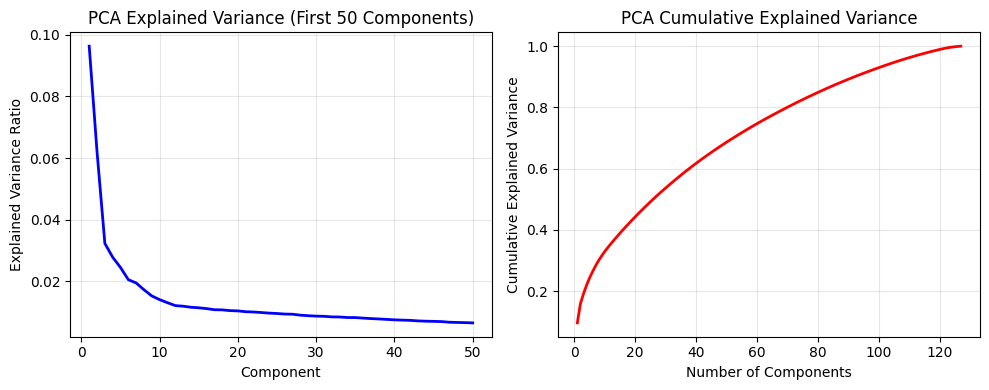

Plotting first two PCA components with metadata coloring...


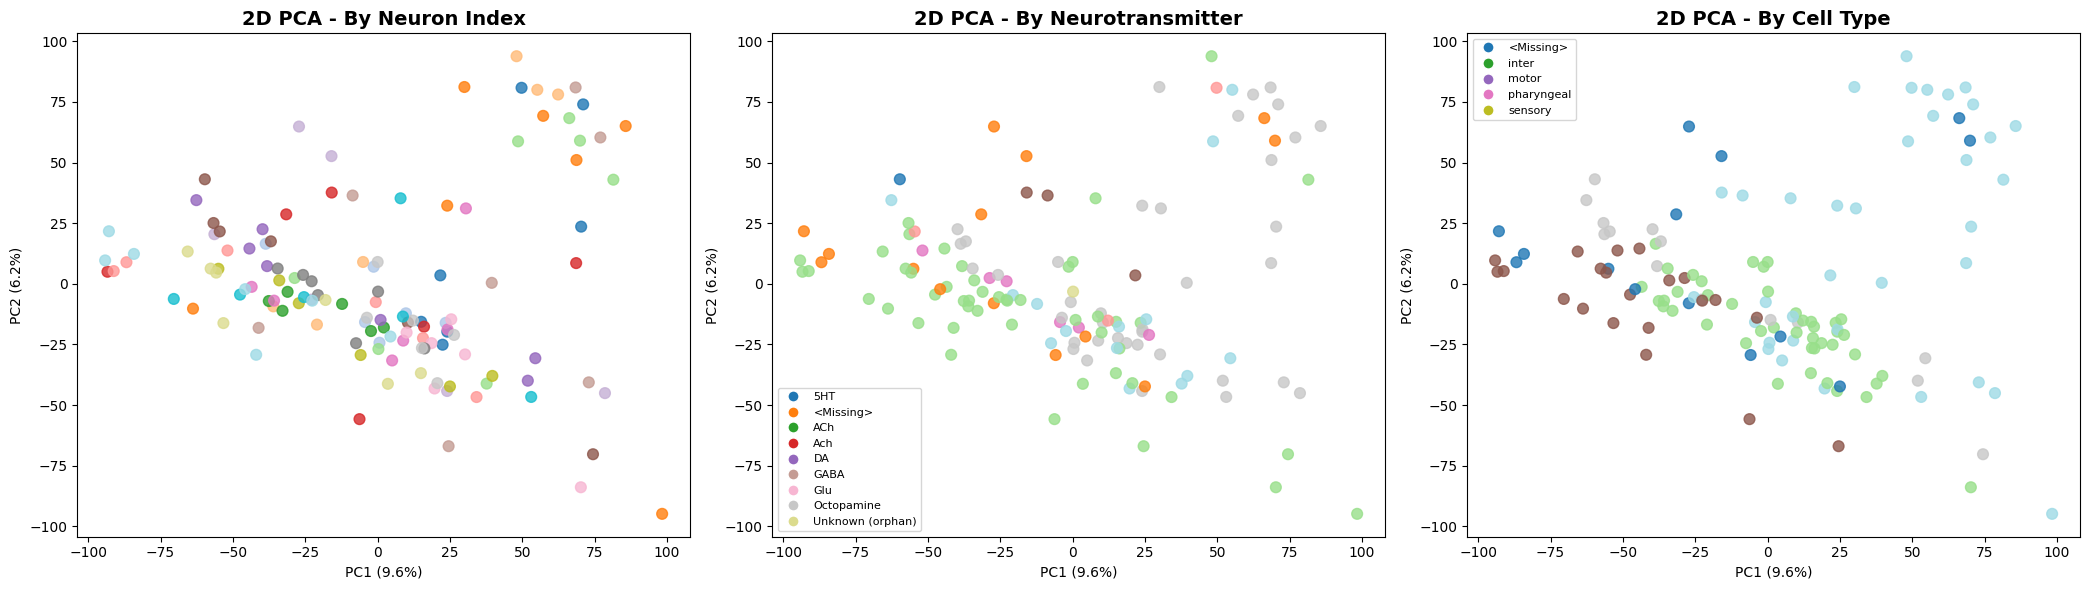

PCA visualization complete
X_pca shape: (128, 127)
Number of neurons: 128
Number of principal components: 127


In [50]:
print(f"PCA preprocessed data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca_preprocess.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca_preprocess.explained_variance_ratio_.sum():.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(50, len(pca_preprocess.explained_variance_ratio_)) + 1), 
         pca_preprocess.explained_variance_ratio_[:50], 'b-', linewidth=2)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_preprocess.explained_variance_ratio_) + 1), 
         np.cumsum(pca_preprocess.explained_variance_ratio_), 'r-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot first two PCA components for visualization with metadata coloring
print("Plotting first two PCA components with metadata coloring...")

# Create figure with 3 subplots: original coloring, neurotransmitter, cell type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot 1: Original (by neuron index)
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Index', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot 2: Colored by neurotransmitter
ax = axes[1]
unique_nt = np.unique(neuron_neurotransmitters)
nt_to_color = {nt: i for i, nt in enumerate(unique_nt)}
nt_colors = [nt_to_color[nt] for nt in neuron_neurotransmitters]

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=nt_colors, cmap='tab20', s=60, alpha=0.8)
ax.set_title('2D PCA - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=plt.cm.tab20(nt_to_color[nt]/len(unique_nt)), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by cell type
ax = axes[2]
unique_types = np.unique(neuron_types)
type_to_color = {t: i for i, t in enumerate(unique_types)}
type_colors = [type_to_color[t] for t in neuron_types]

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=type_colors, cmap='tab20', s=60, alpha=0.8)
ax.set_title('2D PCA - By Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for types
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=plt.cm.tab20(type_to_color[t]/len(unique_types)), 
                     markersize=8, label=t) for t in unique_types]
ax.legend(handles=handles, loc='best', fontsize=8)

plt.tight_layout()
plt.show()

print("PCA visualization complete")
print(f"X_pca shape: {X_pca.shape}")
print(f"Number of neurons: {N_neurons}")
print(f"Number of principal components: {X_pca.shape[1]}")


In [51]:
# Calculate minimum dimension needed for JL lemma
n_samples = N_neurons  # We're preserving distances between neurons
epsilon = CONFIG['jl_epsilon']
min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=epsilon)

print(f"JL minimum dimension for n={n_samples}, eps={epsilon}: {min_dim}")
print(f"Original dimension: {X_original.shape[1]}")

# Use this as our embedding dimension (update CONFIG if needed)
embedding_dim = min_dim.item()
print(f"Using embedding_dim = {embedding_dim}")

# Update CONFIG with the calculated dimension
print(f"Updating CONFIG['embedding_dim'] from {CONFIG['embedding_dim']} to {embedding_dim}")
CONFIG['embedding_dim'] = embedding_dim

# Create and fit GaussianRandomProjection
grp = GaussianRandomProjection(n_components=embedding_dim, eps=epsilon)
X_projected = grp.fit_transform(X_original)

print(f"\nGaussian Random Projection output shape: {X_projected.shape}")
print(f"Projection matrix shape: {grp.components_.shape}")


JL minimum dimension for n=128, eps=0.3: 539
Original dimension: 127
Using embedding_dim = 539
Updating CONFIG['embedding_dim'] from 4096 to 539

Gaussian Random Projection output shape: (128, 539)
Projection matrix shape: (539, 127)


## 4. Custom Dataset with Johnson-Lindenstrauss Random Projection Augmentation

Since we have only one (N, D) embedding matrix from the original transcriptome data, we need to generate multiple training samples. Our innovation is to create synthetic but meaningful variations using Johnson-Lindenstrauss random Gaussian projections.

**Key insight**: Each random projection preserves pairwise distances between neurons with high probability (JL lemma guarantee), while creating novel projections. This allows generation of effectively unlimited training samples with theoretically grounded distance preservation.


In [52]:
class GaussianProjectionDataset(Dataset):
    """Dataset that generates augmented embeddings using sklearn GaussianRandomProjection."""
    
    def __init__(self, X_original, num_samples, embedding_dim, epsilon, seed=None, precompute=None):
        """
        Args:
            X_original: (N, D_original) numpy array of preprocessed transcriptome data
            num_samples: total number of augmented samples to generate
            embedding_dim: target dimension for random projection
            epsilon: JL epsilon parameter for distance preservation
            seed: base random seed for reproducibility
            precompute: if True, precompute all samples in __init__ for faster training
        """
        self.X_original = X_original  # (N_neurons, D_genes)
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.epsilon = epsilon
        self.seed = seed
        self.precompute = num_samples <= 100 if precompute is None else precompute
        
        self.N, self.D_original = X_original.shape
        print(f"Dataset: {self.N} neurons, {self.D_original} → {embedding_dim} dims, {num_samples} samples")
        
        if self.precompute:
            # Precompute all samples once in memory
            start_time = time.time()
            self.samples = []
            
            for idx in range(num_samples):
                sample = self.compute_sample(idx)
                self.samples.append(sample)
            
            end_time = time.time()
            duration = end_time - start_time
            print(f"Precomputed {len(self.samples)} samples in {duration:.2f} seconds ({duration/len(self.samples):.2f} seconds per sample)")
        else:
            # We will compute samples on the fly in __getitem__
            self.samples = None

    def compute_sample(self, idx):
        # Create a GaussianRandomProjection with unique seed for this sample
        if self.seed is not None:
            random_state = self.seed + idx
        else:
            random_state = idx
            
        projector = GaussianRandomProjection(
            n_components=self.embedding_dim,
            eps=self.epsilon,
            random_state=random_state
        )
        
        # Fit and transform the data
        X_projected = projector.fit_transform(self.X_original)  # (N_neurons, embedding_dim)

        # Convert to a tensor and move to device
        X_tensor = torch.tensor(X_projected, dtype=torch.float32, device=device)
        
        return X_tensor

    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if self.precompute:
            return self.samples[idx]
        else:
            return self.compute_sample(idx)


# Test the dataset creation
print("Testing the GaussianProjectionDataset...")
dataset = GaussianProjectionDataset(
    X_original=X_original,
    num_samples=101,  # Test with smaller number first
    embedding_dim=embedding_dim,
    epsilon=CONFIG['jl_epsilon'],
    seed=42,
    precompute=True
)

# Test a few samples
sample = dataset[0]
print(f"\nSample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Sample mean (first 3 neurons): {sample.mean(dim=-1)[:3]}")
print(f"Sample std (first 3 neurons): {sample.std(dim=-1)[:3]}")

# Test that different samples are different
sample2 = dataset[1]
diff = torch.norm(sample - sample2).item()
print(f"Difference between samples 0 and 1: {diff:.3f}")

sampleN = dataset[-1]
diff = torch.norm(sample - sampleN).item()
print(f"Difference between samples 0 and {len(dataset)-1}: {diff:.3f}")

# Create data loader
dataloader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)
batch = next(iter(dataloader))
print(f"Batch shape: {batch.shape}")
print(f"Batch dtype: {batch.dtype}")

Testing the GaussianProjectionDataset...
Dataset: 128 neurons, 127 → 539 dims, 101 samples
Precomputed 101 samples in 0.18 seconds (0.00 seconds per sample)

Sample shape: torch.Size([128, 539]), dtype: torch.float32
Sample mean (first 3 neurons): tensor([ 0.3459,  0.0720, -0.3305], device='mps:0')
Sample std (first 3 neurons): tensor([5.9517, 6.3787, 6.7681], device='mps:0')
Difference between samples 0 and 1: 2320.727
Difference between samples 0 and 100: 2311.730
Batch shape: torch.Size([64, 128, 539])
Batch dtype: torch.float32


### Sanity Check: Johnson-Lindenstrauss Distance Preservation

Let's verify that our random projection augmentation preserves pairwise distances between neurons (JL lemma guarantee). We'll compare pairwise distance correlations between different random projections.


Performing sanity check on Johnson-Lindenstrauss distance preservation...
Dataset: 128 neurons, 127 → 539 dims, 1 samples
Dataset: 128 neurons, 127 → 539 dims, 1 samples

JL Distance Preservation Results:
Original shape: (128, 127)
Sample 1 shape: (128, 539)
Sample 2 shape: (128, 539)
Correlation between pairwise distances (original vs sample1): 0.9746
Correlation between pairwise distances (original vs sample2): 0.9735
Correlation between pairwise distances (sample1 vs sample2): 0.9538
Expected minimum correlation (1-ε): 0.700
Actual correlation (mean of 3) : 0.967
✓ PASS: JL distance preservation working correctly!


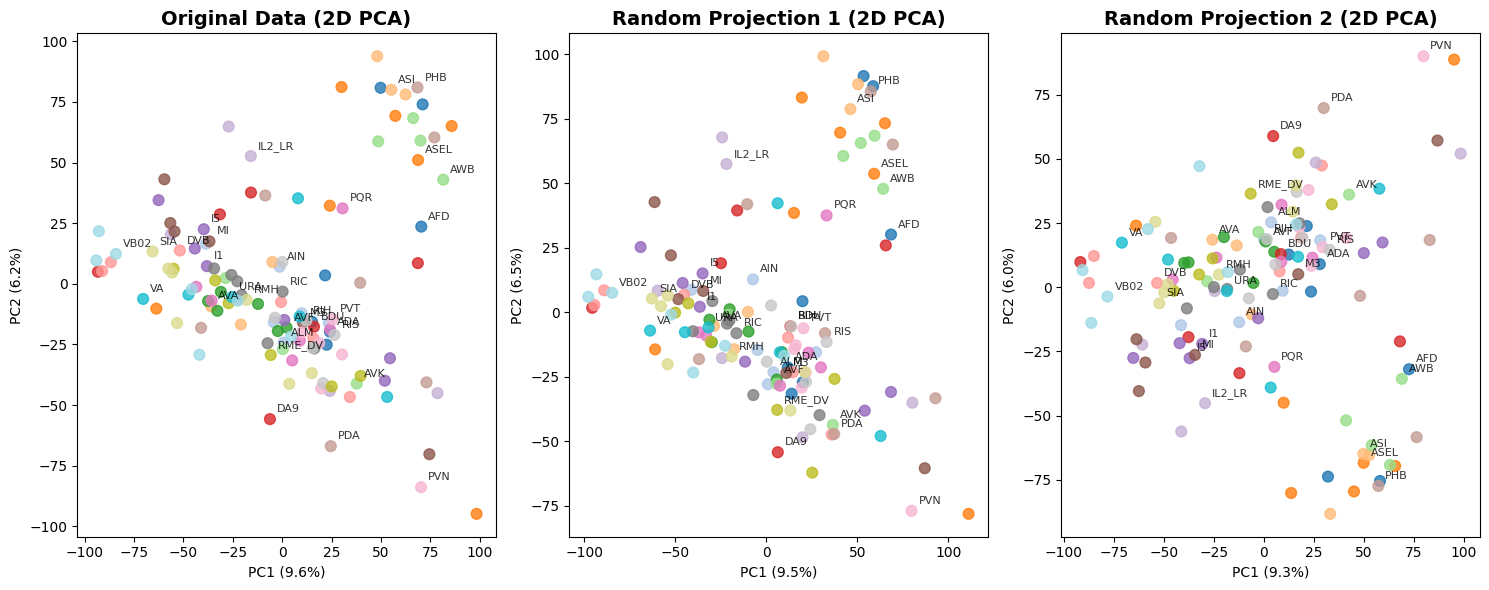

In [53]:
# Sanity check: Test JL distance preservation between random projections
print("Performing sanity check on Johnson-Lindenstrauss distance preservation...")

# Generate two different random projections
test_dataset1 = GaussianProjectionDataset(
    X_original=X_original,
    num_samples=1,
    embedding_dim=embedding_dim,
    epsilon=CONFIG['jl_epsilon'],
    seed=1000,
    precompute=False
)

test_dataset2 = GaussianProjectionDataset(
    X_original=X_original,
    num_samples=1,
    embedding_dim=embedding_dim,
    epsilon=CONFIG['jl_epsilon'],
    seed=2000,
    precompute=False
)

sample0 = X_original # Shape: (N, D_original)
sample1 = test_dataset1[0].cpu().numpy()  # Shape: (N, D_embedding)
sample2 = test_dataset2[0].cpu().numpy()  # Shape: (N, D_embedding)

# Compute pairwise distances for both projections
distances0 = pdist(X_original)
distances1 = pdist(sample1)
distances2 = pdist(sample2)

# Calculate correlation between distance matrices
correlation_01 = np.corrcoef(distances0, distances1)[0, 1]
correlation_02 = np.corrcoef(distances0, distances2)[0, 1]
correlation_12 = np.corrcoef(distances1, distances2)[0, 1]

print(f"\nJL Distance Preservation Results:")
print(f"Original shape: {X_original.shape}")
print(f"Sample 1 shape: {sample1.shape}")
print(f"Sample 2 shape: {sample2.shape}")
print(f"Correlation between pairwise distances (original vs sample1): {correlation_01:.4f}")
print(f"Correlation between pairwise distances (original vs sample2): {correlation_02:.4f}")
print(f"Correlation between pairwise distances (sample1 vs sample2): {correlation_12:.4f}")

# Get the mean of the 3 pairwise correlations
mean_correlation = (correlation_01 + correlation_02 + correlation_12) / 3

# Test JL lemma bounds
# JL lemma: (1-ε)||x-y||² ≤ ||Px-Py||² ≤ (1+ε)||x-y||²
# So correlation should be high (close to 1) for good distance preservation
epsilon = CONFIG['jl_epsilon']
expected_min_correlation = 1 - epsilon  # Rough approximation

print(f"Expected minimum correlation (1-ε): {expected_min_correlation:.3f}")
print(f"Actual correlation (mean of 3) : {mean_correlation:.3f}")

if mean_correlation > expected_min_correlation:
    print("✓ PASS: JL distance preservation working correctly!")
else:
    print("⚠ WARNING: Distance preservation may not meet JL bounds")

# Visualize with 2D PCA for both samples
pca1_2d = PCA(n_components=2, random_state=42)
pca2_2d = PCA(n_components=2, random_state=43)

# Fit PCA on first sample and transform both
sample1_pca = pca1_2d.fit_transform(sample1)
sample2_pca = pca2_2d.fit_transform(sample2)

# Create comparison plot
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 6))

# Create a consistent color mapping for neurons
unique_colors = plt.cm.tab20(np.linspace(0, 1, len(neuron_classes)))
color_dict = dict(zip(neuron_classes, unique_colors))
colors = [color_dict[neuron] for neuron in neuron_classes]

# Plot original 
scatter0 = ax0.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax0.set_title('Original Data (2D PCA)', fontsize=14, fontweight='bold')
ax0.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax0.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Plot sample 1
scatter1 = ax1.scatter(sample1_pca[:, 0], sample1_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax1.set_title('Random Projection 1 (2D PCA)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca1_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca1_2d.explained_variance_ratio_[1]:.1%})')

# Plot sample 2
scatter2 = ax2.scatter(sample2_pca[:, 0], sample2_pca[:, 1], 
                      c=colors, s=60, alpha=0.8)
ax2.set_title('Random Projection 2 (2D PCA)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca2_2d.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca2_2d.explained_variance_ratio_[1]:.1%})')

# Annotate a few points for reference
for i in range(0, len(neuron_classes), 4):  # Annotate every 4th neuron
    ax0.annotate(neuron_classes[i], (X_pca[i, 0], X_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax1.annotate(neuron_classes[i], (sample1_pca[i, 0], sample1_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    ax2.annotate(neuron_classes[i], (sample2_pca[i, 0], sample2_pca[i, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()


In [58]:
# Batch Consistency Loss Functions

def batch_consistency_loss_cosine(attn_matrices):
    """
    Encourage batch items to have high pairwise cosine similarity.
    This is the recommended/default approach.
    
    Args:
        attn_matrices: (B, N, N) tensor
    
    Returns:
        scalar loss: negative mean pairwise cosine similarity
    """
    B, N, _ = attn_matrices.shape
    
    # Flatten each matrix: (B, N*N)
    flat = attn_matrices.view(B, -1)
    
    # Compute pairwise cosine similarities
    # Normalize each row
    flat_norm = flat / (flat.norm(dim=1, keepdim=True) + 1e-8)
    
    # Cosine similarity matrix: (B, B)
    cos_sim = torch.mm(flat_norm, flat_norm.t())
    
    # Get upper triangular (exclude diagonal)
    mask = torch.triu(torch.ones(B, B, device=attn_matrices.device), diagonal=1)
    pairwise_sims = cos_sim[mask.bool()]
    
    # Return negative mean (minimize negative = maximize similarity)
    return -pairwise_sims.mean()

def batch_consistency_loss_variance(attn_matrices, reduction='mean'):
    """
    Compute variance across batch dimension to encourage consistency.
    Alternative to cosine similarity approach.
    
    Args:
        attn_matrices: (B, N, N) tensor of attention weights or scores
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: variance across batch dimension, averaged over all (i,j) pairs
    """
    # Compute variance across batch dimension for each (i,j) position
    # var(dim=0) gives (N, N) tensor of variances
    batch_variance = torch.var(attn_matrices, dim=0, unbiased=False)  # (N, N)
    
    if reduction == 'mean':
        return batch_variance.mean()  # Average variance across all positions
    elif reduction == 'sum':
        return batch_variance.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")

print("Batch consistency loss functions defined:")
print("  - batch_consistency_loss_cosine (recommended)")
print("  - batch_consistency_loss_variance (alternative)")


Batch consistency loss functions defined:
  - batch_consistency_loss_cosine (recommended)
  - batch_consistency_loss_variance (alternative)


## 5. Attention Model Architecture with Random Dropout Masking

We implement the `SingleHeadSelfAttention` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovations are:
1. Diagonal masking that prevents self-attention
2. Random dropout masking during training that forces robust attention patterns

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Random dropout mask: During training, randomly mask 1 additional neuron per row to prevent overfitting


### The Decoder part of the Transformer Architecture

![Decoder Architecture](figures/transformer_decoder.png)


In [59]:
# TODO: Encapsulate a custom decoder layer into a class. 
# We may want to use a deep Transformer that stacks multiple Attention (and MLP) layers.

## Mistral example of how to implement a decoder layer
# class MistralDecoderLayer(GradientCheckpointingLayer):
#     def __init__(self, config: MistralConfig, layer_idx: int):
#         super().__init__()
#         self.hidden_size = config.hidden_size
#         self.self_attn = MistralAttention(config=config, layer_idx=layer_idx)
#         self.mlp = MistralMLP(config)
#         self.input_layernorm = MistralRMSNorm(config.hidden_size, eps=config.rms_norm_eps)
#         self.post_attention_layernorm = MistralRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

#     @deprecate_kwarg("past_key_value", new_name="past_key_values", version="4.58")
#     def forward(
#         self,
#         hidden_states: torch.Tensor,
#         attention_mask: Optional[torch.Tensor] = None,
#         position_ids: Optional[torch.LongTensor] = None,
#         past_key_values: Optional[Cache] = None,
#         use_cache: Optional[bool] = False,
#         cache_position: Optional[torch.LongTensor] = None,
#         position_embeddings: Optional[tuple[torch.Tensor, torch.Tensor]] = None,  # necessary, but kept here for BC
#         **kwargs: Unpack[TransformersKwargs],
#     ) -> torch.Tensor:
#         residual = hidden_states
#         hidden_states = self.input_layernorm(hidden_states)
#         # Self Attention
#         hidden_states, _ = self.self_attn(
#             hidden_states=hidden_states,
#             attention_mask=attention_mask,
#             position_ids=position_ids,
#             past_key_values=past_key_values,
#             use_cache=use_cache,
#             cache_position=cache_position,
#             position_embeddings=position_embeddings,
#             **kwargs,
#         )
#         hidden_states = residual + hidden_states

#         # Fully Connected
#         residual = hidden_states
#         hidden_states = self.post_attention_layernorm(hidden_states)
#         hidden_states = self.mlp(hidden_states)
#         hidden_states = residual + hidden_states
#         return hidden_states

In [67]:
# TODO: Figure out how to implement multi-head self-attention
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False, verbose_timing=False):
        """
        A single head of self-attention that projects input tokens to queries, keys and values.
        The value projection implements an identity function (i.e. the values `V` will equal the input `x`) 
        so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use raw attention scores instead of softmax weights
            verbose_timing: if True, print timing information for each step
        """
        super().__init__()
        # Q, K, and V projections
        self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
        self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection; Using Identity means values = inputs
        # NOTE: If we were to use multiple heads: 
        # W_Q and W_K would be torch.nn.Linear(d_model, n_hidden*num_heads, bias=False)
        # W_V would be num_heads Identity matrices vertically stacked 
        #     i.e. matrix shape (output_dim, input_dim) = (num_heads*d_model, d_model)
        #     id = torch.eye(d_model); param = torch.nn.Parameter( torch.concat( num_heads * (id, ) ), requires_grad=False )
        #     W_V = torch.nn.Linear(d_model, num_heads*d_model, bias=False); W_V.weight = param; 
        #     Just to make sure: [ param.requires_grad_(False) for param in W_V.parameters() ]
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.verbose_timing = verbose_timing

    def forward(self, x, attn_mask=None, mask_other=False):
        """
        NOTE: Tokens in are the same shape as the tokens out (batch, n_neurons, d_model).
        Args:
            x: input token tensor (i.e. embeddings) of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons); defaults to diagonal 'self' mask.
            mask_other: if True, radnomly mask out one additional random neuron (besides self) per row of the attention matrix

        Returns:
            reconstructed: reconstructed embeddings of shape (batch, n_neurons, d_model)
            attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
            attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
        """
        start_time = time.time()
        batch_size, n_neurons, d_model = x.shape
        device = x.device

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)
        # # NOTE: If we were to use multiple heads:
        # Q = self.W_Q(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # K = self.W_K(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # V = self.W_V(x).view((batch, n_neurons, -1, self.d_model)).transpose(1, 2) # (batch, num_heads, n_neurons, d_model)
        print(f"QK/V projections done in {time.time() - start_time:.3f}s") if self.verbose_timing else None

        # Create base diagonal mask (1 everywhere except diagonal)
        mask_time = time.time()
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_neurons, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # During training, mask one additional random neuron per row
        if mask_other: # NOTE: This will be significantly slower than the diagonal masking
            # Clone mask to avoid modifying the original
            attn_mask = attn_mask.clone()
            
            # For each sample in batch, for each neuron (row), randomly mask 1 additional non-self neuron
            # TODO: Parallelize this so we don't have a double for loop
            for b in range(batch_size):
                for i in range(n_neurons):
                    # Get indices of non-self neurons (where mask is currently 1)
                    non_self_indices = torch.where(attn_mask[b, i, :] == 1)[0]
                    
                    # Randomly select 1 index to mask out
                    if len(non_self_indices) > 0:
                        rand_idx = torch.randint(0, len(non_self_indices), (1,), device=device)
                        neuron_to_mask = non_self_indices[rand_idx]
                        attn_mask[b, i, neuron_to_mask] = 0
        
        print(f"Attention masking done in {time.time() - mask_time:.3f}s") if self.verbose_timing else None

        # Compute attention
        attn_time = time.time()
        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        print(f"Attention computation done in {time.time() - attn_time:.3f}s") if self.verbose_timing else None

        # Apply attention to values
        recon_time = time.time()
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        print(f"Reconstruction done in {time.time() - recon_time:.3f}s") if self.verbose_timing else None
        print(f"Total forward pass time: {time.time() - start_time:.3f}s") if self.verbose_timing else None

        return reconstructed, attn_weights, attn_scores


In [68]:
# Test the attention model
print("Testing SingleHeadSelfAttention model...")
print(f"Using device: {device}")

# Create model
model = SingleHeadSelfAttention(
    d_model=CONFIG['embedding_dim'],
    n_hidden=CONFIG['hidden_dim'],
    use_attention_scores=CONFIG['use_attention_scores']
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")

Testing SingleHeadSelfAttention model...
Using device: mps
Model created with 275968 parameters


In [72]:
# Test with a batch
test_batch = batch.to(device)  # (batch_size, n_neurons, d_model)
print(f"Test batch shape: {test_batch.shape}")

# Test with additional masking of one other neuron per row
model.train()
with torch.no_grad():
    start_time = time.time()
    reconstructed_other, attn_weights_other, attn_scores_other = model(test_batch, mask_other=True)
    print(f"Masking other mode done in {time.time() - start_time:.3f}s")

print(f"Masking other mode - Reconstructed shape: {reconstructed_other.shape}")
print(f"Masking other mode - Attention weights shape: {attn_weights_other.shape}")
print(f"Masking other mode - Attention scores shape: {attn_scores_other.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights_other = torch.diagonal(attn_weights_other[0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights_other[:5]}")

# Check reconstruction error
reconstruction_error_other = torch.norm(test_batch - reconstructed_other, dim=-1).mean()
print(f"Initial reconstruction error (masking other mode): {reconstruction_error_other:.3f}")

# Test regular mode where just the diagonal (self-reference) is masked
model.eval()
with torch.no_grad():
    start_time = time.time()
    reconstructed_regular, attn_weights_regular, attn_scores_regular = model(test_batch, mask_other=False)
    print(f"Diagonal masking mode done in {time.time() - start_time:.3f}s")

print()
print(f"Diagonal masking mode - Reconstructed shape: {reconstructed_regular.shape}")
print(f"Diagonal masking mode - Attention weights shape: {attn_weights_regular.shape}")

# Check that diagonal is zero in attention weights
diagonal_weights_regular = torch.diagonal(attn_weights_regular[0], dim1=0, dim2=1)
print(f"Diagonal attention weights (should be ~0): {diagonal_weights_regular[:5]}")

# Check reconstruction error
reconstruction_error_regular = torch.norm(test_batch - reconstructed_regular, dim=-1).mean()
print(f"Initial reconstruction error (diagonal masking mode): {reconstruction_error_regular:.3f}")

# Check that diagonal masking and random masking modes produce different results 
diff = torch.norm(attn_weights_other - attn_weights_regular).item()
print(f"\nDifference between regular and other attention weights: {diff:.3f}")
if diff > 0.01:
    print("✓ Random dropout masking is working - training and eval modes differ")
else:
    print("⚠ Random dropout masking may not be working properly")


Test batch shape: torch.Size([64, 128, 539])
Masking other mode done in 8.342s
Masking other mode - Reconstructed shape: torch.Size([64, 128, 539])
Masking other mode - Attention weights shape: torch.Size([64, 128, 128])
Masking other mode - Attention scores shape: torch.Size([64, 128, 128])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.], device='mps:0')
Initial reconstruction error (masking other mode): 206.476
Diagonal masking mode done in 0.000s

Diagonal masking mode - Reconstructed shape: torch.Size([64, 128, 539])
Diagonal masking mode - Attention weights shape: torch.Size([64, 128, 128])
Diagonal attention weights (should be ~0): tensor([0., 0., 0., 0., 0.], device='mps:0')
Initial reconstruction error (diagonal masking mode): 206.532

Difference between regular and other attention weights: 9.940
✓ Random dropout masking is working - training and eval modes differ


## 6. Training Loop with Reconstruction Loss and Train/Val Split

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".

We now use proper train/validation split with different random projections for each set.


In [ ]:
# Set up training
criterion = nn.L1Loss() #nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=50)

# Set the total train and val samples
n_train_samples = CONFIG['num_samples']  
n_val_samples = CONFIG['batch_size'] # Single batch validation
print(f"Creating datasets: {n_train_samples} train, {n_val_samples} val")

# Create datasets
print("Creating training and validation datasets...")
train_dataset = GaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_train_samples,
    embedding_dim=embedding_dim,
    epsilon=CONFIG['jl_epsilon'],
    seed=42,
    precompute=False
)

val_dataset = GaussianProjectionDataset(
    X_original=X_original,
    num_samples=n_val_samples,
    embedding_dim=embedding_dim,
    epsilon=CONFIG['jl_epsilon'],
    seed=42 + n_train_samples,  # Different seed for validation
    precompute=True
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False) 

# Get count of number of batches
n_train_batches = len(train_loader)
n_val_batches = len(val_loader)

# Track losses per batch
train_losses = []
val_losses = []
batch_numbers = []

num_epochs = CONFIG['num_epochs']

print("\nStarting training...")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Embedding dimension: {embedding_dim}")
print(f"JL epsilon: {CONFIG['jl_epsilon']}")
print(f"Training samples: {n_train_samples}")
print(f"Validation samples: {n_val_samples}")
print(f"Training batches per epoch: {n_train_batches}")
print(f"Validation batches per epoch: {n_val_batches}\n")

total_start_time = time.time()
total_batches = 0

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    epoch_start_time = time.time()
    
    # Training phase
    model.train()
    for batch_idx, train_batch in enumerate(train_loader):
        total_batches += 1
        train_batch = train_batch.to(device)
        
        # Training forward pass
        train_reconstructed, train_attn_weights, train_attn_scores = model(train_batch, mask_other=False)
        train_loss = criterion(train_reconstructed, train_batch)
        
        # Training backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        train_losses.append(train_loss.item())
        batch_numbers.append(total_batches)
        
        # Validation after each training batch
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)
                val_reconstructed, _, _ = model(val_batch, mask_other=False)
                val_loss = criterion(val_reconstructed, val_batch)
                batch_val_losses.append(val_loss.item())
        
        # Record average validation loss for this batch
        avg_val_loss = np.mean(batch_val_losses)
        val_losses.append(avg_val_loss.item())
        
        # Step the scheduler based on validation loss
        scheduler.step(avg_val_loss.item())
        
        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"\tBatch {total_batches}/{n_train_batches} - Train Loss: {train_loss.item():.6f}, Val Loss: {avg_val_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    epoch_time = time.time() - epoch_start_time
    print(f"Epoch {epoch + 1} completed in {epoch_time:.2f}s")

total_time = time.time() - total_start_time
print(f"\nTraining completed in {total_time:.2f}s ({total_time/60:.2f} min)")

Creating datasets: 12800 train, 64 val
Creating training and validation datasets...
Dataset: 128 neurons, 127 → 539 dims, 12800 samples
Dataset: 128 neurons, 127 → 539 dims, 64 samples
Precomputed 64 samples in 0.11 seconds (0.00 seconds per sample)

Starting training...
Number of epochs: 1
Batch size: 64
Learning rate: 0.001
Embedding dimension: 539
JL epsilon: 0.3
Training samples: 12800
Validation samples: 64
Training batches per epoch: 200
Validation batches per epoch: 1

Epoch 1/1
	Batch 10/200 - Train Loss: 6.958040, Val Loss: 6.937282, LR: 0.001000
	Batch 20/200 - Train Loss: 6.762419, Val Loss: 6.688875, LR: 0.001000
	Batch 30/200 - Train Loss: 6.493797, Val Loss: 6.437367, LR: 0.001000
	Batch 40/200 - Train Loss: 6.256248, Val Loss: 6.219582, LR: 0.001000
	Batch 50/200 - Train Loss: 6.146529, Val Loss: 6.108250, LR: 0.001000
	Batch 60/200 - Train Loss: 6.048271, Val Loss: 6.040550, LR: 0.001000
	Batch 70/200 - Train Loss: 5.997126, Val Loss: 6.004739, LR: 0.001000
	Batch 80/20


Plotting loss curves...


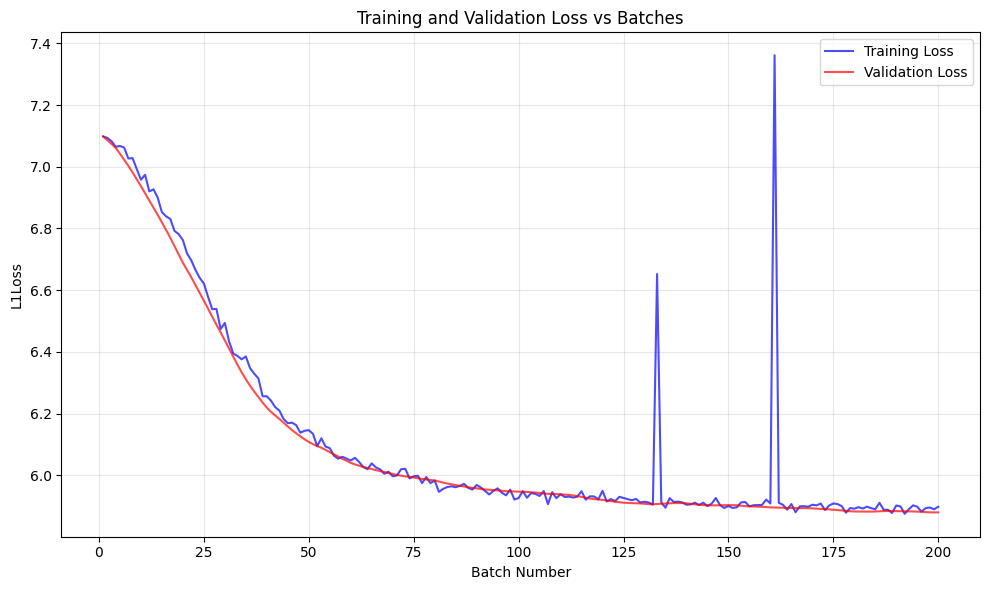


Training Summary:
Final training loss: 5.898220
Final validation loss: 5.879978
Best training loss: 5.875469
Best validation loss: 5.879978


In [15]:
# Plot training and validation loss curves against batches
print("\nPlotting loss curves...")
plt.figure(figsize=(10, 6))

# Plot both curves
plt.plot(batch_numbers, train_losses, alpha=0.7, label='Training Loss', color='blue')
plt.plot(batch_numbers, val_losses, alpha=0.7, label='Validation Loss', color='red')

plt.xlabel('Batch Number')
plt.ylabel(f"{str(criterion).strip('()')}")
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTraining Summary:")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best training loss: {min(train_losses):.6f}")
print(f"Best validation loss: {min(val_losses):.6f}")

## 6. Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


Extracting learned attention on multiple sample projections...
Dataset: 128 neurons, 127 → 539 dims, 64 samples
Precomputed 64 samples in 0.10 seconds (0.00 seconds per sample)
Reconstruction L1Loss on sample embeddings: 5.884181
Using attention weights
Learned attention matrix shape: (128, 128)
Attention matrix stats - mean: 0.007812, std: 0.044193
Attention matrix range: [0.000000, 0.999999]


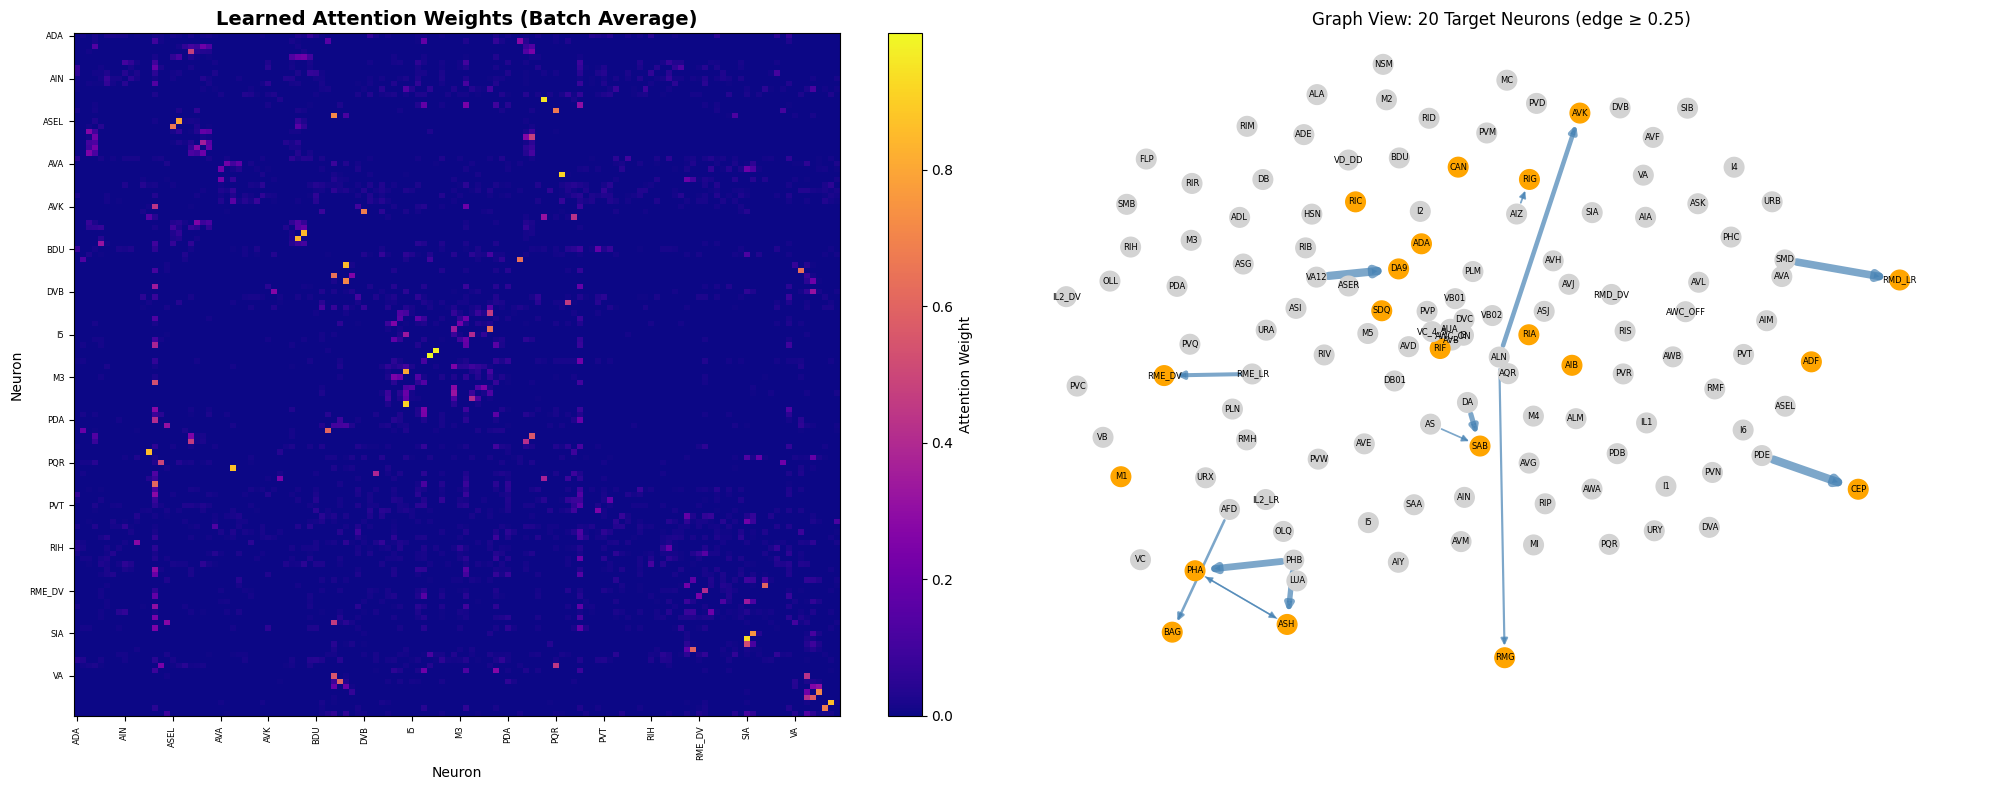

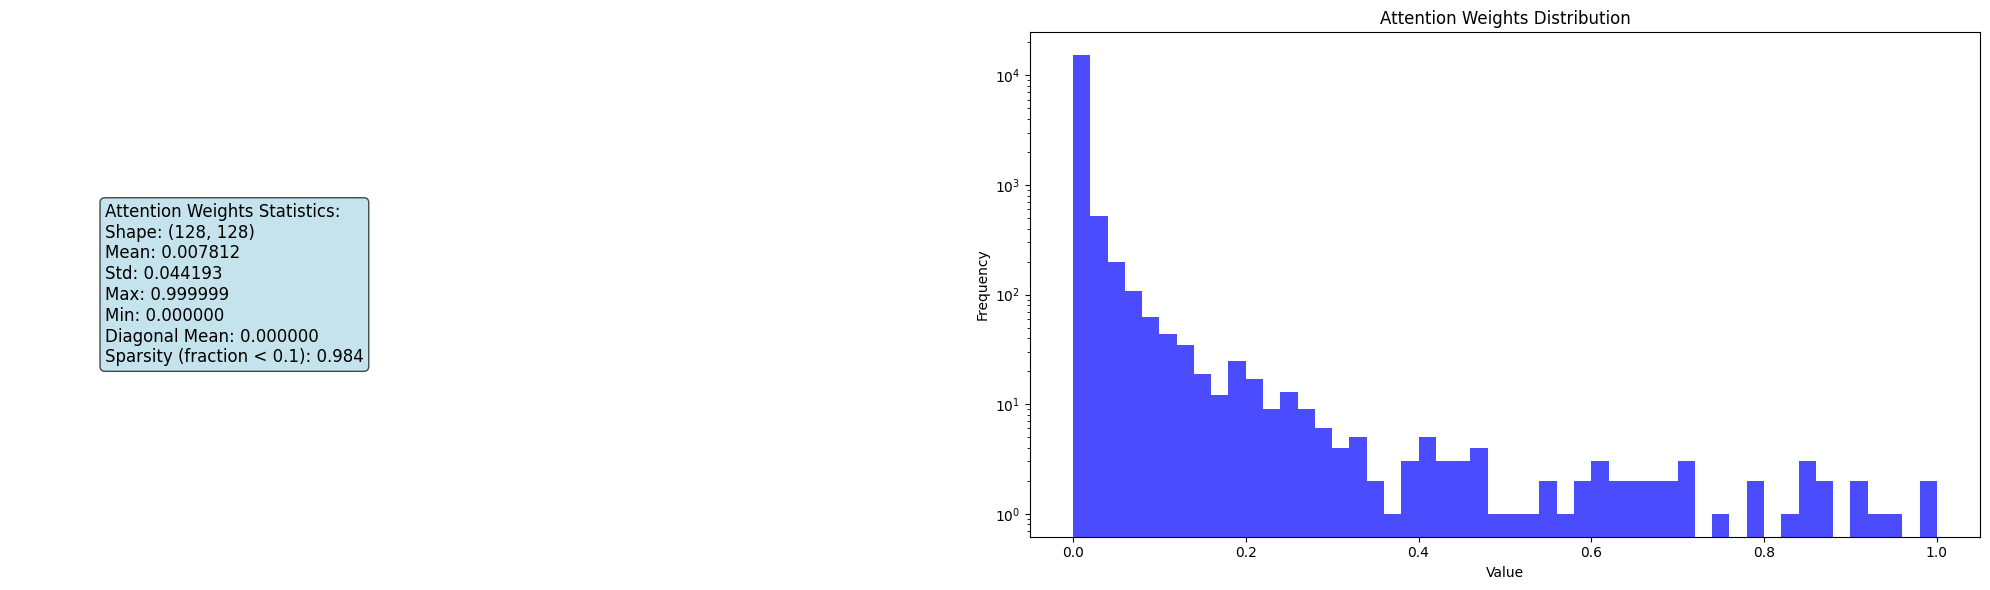


Summary (Batch Average):
Reconstruction L1Loss (attention): 5.884181
Attention weights sparsity@0.1: 0.984


In [ ]:
# Evaluate average learned attention on a batch of sample projections and visualize

print("Extracting learned attention on multiple sample projections...")
model.eval()
with torch.no_grad():
    # Generate multiple samples for evaluation (using seed 9999 to avoid training data)
    viz_dataset = GaussianProjectionDataset(
        X_original=X_original,
        num_samples=CONFIG['batch_size'], 
        embedding_dim=embedding_dim,
        epsilon=CONFIG['jl_epsilon'],
        seed=9999, # Use a seed that is squarely outside the range of the train and val data
        precompute=True
    )
    
    # Create a batch from all samples
    test_batch = torch.stack(list(viz_dataset)).to(device)  # (num_samples, N, D)

    reconstructed_orig, attn_weights, attn_scores = model(test_batch, mask_other=False)

# Compute reconstruction loss on sample embeddings
with torch.no_grad():
    recon_loss = criterion(reconstructed_orig, test_batch).item()
    print(f"Reconstruction {str(criterion).strip('()')} on sample embeddings: {recon_loss:.6f}")

# Choose which attention matrix to use based on configuration
if CONFIG['use_attention_scores']:
    # Use attention scores (can be negative)
    avg_attention = attn_scores.mean(dim=0).cpu().numpy()  # (N, N)
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    # Use attention weights (non-negative, sum to 1)
    avg_attention = attn_weights.mean(dim=0).cpu().numpy()  # (N, N)
    attention_type = "weights"
    attention_label = "Attention Weight"

attention_matrix = avg_attention

# Always use attention weights for sparsity calculations
attention_weights_matrix = attn_weights.mean(dim=0).cpu().numpy()  # (N, N)
attn_sparsity_thresh = 0.1
attention_sparsity_val = (attention_weights_matrix < attn_sparsity_thresh).sum() / attention_weights_matrix.size

print(f"Using attention {attention_type}")
print(f"Learned attention matrix shape: {attention_matrix.shape}")
print(f"Attention matrix stats - mean: {attention_matrix.mean():.6f}, std: {attention_matrix.std():.6f}")
print(f"Attention matrix range: [{attention_matrix.min():.6f}, {attention_matrix.max():.6f}]")

# First figure: Attention matrix and graph view
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 1) Learned attention matrix with sparsified tick labels
cmap = 'coolwarm' if CONFIG['use_attention_scores'] else 'plasma'
im1 = ax1.imshow(attention_matrix, cmap=cmap, aspect='auto')
ax1.set_title(f'Learned Attention {attention_type.title()} (Batch Average)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Neuron')
ax1.set_ylabel('Neuron')
plt.colorbar(im1, ax=ax1, label=attention_label)
# Label every k-th tick to reduce clutter
k = max(1, len(neuron_classes) // 16)  # ~16 labels per axis
xticks = np.arange(0, len(neuron_classes), k)
ax1.set_xticks(xticks)
ax1.set_xticklabels([neuron_classes[i] for i in xticks], fontsize=6, rotation=90)
ax1.set_yticks(xticks)
ax1.set_yticklabels([neuron_classes[i] for i in xticks], fontsize=6)

# 2) Graph plot for randomly selected target neurons
num_targets = 20
edge_thresh = 0.25  # filter weak edges
targets = np.random.choice(len(neuron_classes), size=num_targets, replace=False)
G = nx.DiGraph()
# Add nodes
for idx in range(len(neuron_classes)):
    G.add_node(idx, label=neuron_classes[idx])

# Add edges to selected targets above threshold (exclude self)
for j in targets:  # j is target
    for i in range(len(neuron_classes)):  # i is source
        if i == j:
            continue
        w = attention_weights_matrix[j, i]  # [target, source] for incoming edges
        if w >= edge_thresh:
            G.add_edge(i, j, weight=w)  # Edge from source i to target j

# Node positions (spectral layout)
pos = nx.forceatlas2_layout(G, scaling_ratio=0.05)
# Draw nodes (highlight selected targets)
node_colors = ['orange' if n in targets else 'lightgray' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, ax=ax2)
# Draw edges with widths ~ weight
if G.number_of_edges() > 0:
    weights = np.array([d['weight'] for (_, _, d) in G.edges(data=True)])
    widths = 1.0 + 5.0 * (weights - weights.min()) / (np.ptp(weights) + 1e-8)
    nx.draw_networkx_edges(G, pos, width=widths, edge_color='steelblue', alpha=0.7, arrows=True, ax=ax2)
# Draw labels for nodes
labels = {n: neuron_classes[n] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, ax=ax2)
ax2.set_title(f'Graph View: {num_targets} Target Neurons (edge ≥ {edge_thresh})')
ax2.axis('off')

plt.tight_layout()
plt.show()

# Second figure: Statistics plots
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# 1) Statistics text box
ax1.axis('off')
stats_text = f"""Attention {attention_type.title()} Statistics:
Shape: {attention_matrix.shape}
Mean: {attention_matrix.mean():.6f}
Std: {attention_matrix.std():.6f}
Max: {attention_matrix.max():.6f}
Min: {attention_matrix.min():.6f}
Diagonal Mean: {np.diag(attention_matrix).mean():.6f}
Sparsity (fraction < {attn_sparsity_thresh}): {attention_sparsity_val:.3f}"""
ax1.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# 2) Value distributions
ax2.hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='blue', label='Attention')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Attention {attention_type.title()} Distribution')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\nSummary (Batch Average):")
print(f"Reconstruction {str(criterion).strip('()')} (attention): {recon_loss:.6f}")
print(f"Attention weights sparsity@{attn_sparsity_thresh}: {attention_sparsity_val:.3f}")

### **Idea**: Does the learned attention matrix better embed neurons? 

If we interpret the attention matrix as a similarity matrix, does it induce a semantically meaningful clustering of neurons, such as by cell-type or neurotransmitters?

We can load additional neuron metadata from `data/neuron_master_sheet.csv` to use as unsupervised labels.

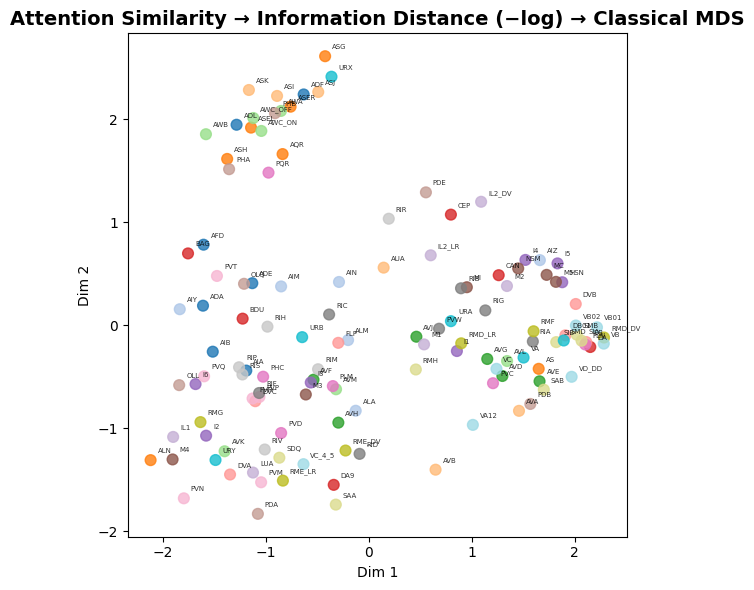

In [17]:
# Demo (Option B): Similarity → Information Distance → Classical MDS
# - Use the learned attention matrix A (rows softmaxed)
# - Symmetrize to get similarity S in [0,1]
# - Convert S to a steeper "information" distance with -log
# - Classical MDS from distances

# ----- Use the learned attention matrix -----
A = attention_matrix
n = A.shape[0]
J = np.eye(n) - np.ones((n, n)) / n

# Symmetrize to get a similarity matrix S \in [0,1]
S = 0.5 * (A + A.T)

# ----- Similarity -> Distance (steeper than sqrt(1-S)) -----
# Information distance: D_ij = sqrt(max(0, -log(S_ij + eps)))
eps = 1e-9
D = np.sqrt(np.maximum(0.0, -np.log(S + eps)))

# ----- Classical MDS from pairwise distances -----
# Double-centering turns squared distances into a centered Gram matrix
B = -0.5 * J @ (D ** 2) @ J

# Eigendecomposition of Gram matrix; take top 2 components
eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

# Keep top 2 nonnegative components (guard against tiny negatives)
k = min(2, int((eigvals > 1e-12).sum()))
coords_mds = eigvecs[:, :k] * np.sqrt(np.maximum(eigvals[:k], 0.0))

# ----- Plot -----
plt.figure(figsize=(15, 6))
plt.scatter(coords_mds[:, 0], coords_mds[:, 1],
            c=range(len(neuron_classes)), cmap='tab20', s=60, alpha=0.8)
plt.title('Attention Similarity → Information Distance (−log) → Classical MDS',
          fontsize=14, fontweight='bold')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')

# Annotate every other neuron for readability
for i in range(0, len(neuron_classes), 1):
    plt.annotate(neuron_classes[i], (coords_mds[i, 0], coords_mds[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=5, alpha=0.8)

# (Optional) make aspect ratio equal for visual comparability
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both structural (wired) and functional connectivity data that we can compare against our learned attention patterns.


In [34]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/connectomics/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/connectomics/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset, filtering out BWM (body-wall muscle) neurons
neurons_7_pre = {n for n in witvliet_7['pre'].unique() if not n.startswith('BWM-')}
neurons_7_post = {n for n in witvliet_7['post'].unique() if not n.startswith('BWM-')}
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = {n for n in witvliet_8['pre'].unique() if not n.startswith('BWM-')}
neurons_8_post = {n for n in witvliet_8['post'].unique() if not n.startswith('BWM-')}
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Intersection of neurons across both datasets
neurons_7_8_overlap = neurons_7_all.intersection(neurons_8_all)

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union: {len(neurons_7_8_all)} neurons")
print(f"Overlap between 7 and 8: {len(neurons_7_8_overlap)} neurons")

# Check overlap with our transcriptome neuron classes
transcriptome_neurons = {n for n in neuron_classes if not n.startswith('BWM-')}
overlap_with_transcriptome = transcriptome_neurons.intersection(neurons_7_8_all)

print(f"\nOverlap with transcriptome data:")
print(f"Combined Witvliet overlap: {len(overlap_with_transcriptome)}/{len(transcriptome_neurons)} ({len(overlap_with_transcriptome)/len(transcriptome_neurons)*100:.1f}%)")
print(f"Sample overlapping neurons: {list(overlap_with_transcriptome)[:10]}")

# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 190 unique neurons
Witvliet 2020-8: 187 unique neurons
Union: 191 neurons
Overlap between 7 and 8: 186 neurons

Overlap with transcriptome data:
Combined Witvliet overlap: 14/128 (10.9%)
Sample overlapping neurons: ['AVL', 'ALA', 'PVR', 'DVA', 'RIS', 'RIR', 'RIH', 

In [35]:
# Convert ground-truth connectome data to combined adjacency matrix
print("Creating combined Witvliet 2020 connectome (averaged and symmetrized)...")

def create_adjacency_matrix(df, neuron_list, weight_col='synapses', synapse_type='chemical'):
    """Create adjacency matrix from connectome dataframe, filtering by synapse type."""
    n_neurons = len(neuron_list)
    adj_matrix = np.zeros((n_neurons, n_neurons))
    
    # Create mapping from neuron names to indices
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}
    
    # Filter for only the specified synapse type
    df_filtered = df[df['type'] == synapse_type]
    print(f"  Using {synapse_type} synapses: {len(df_filtered)} connections")
    
    for _, row in df_filtered.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        weight = row[weight_col]
        
        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adj_matrix[pre_idx, post_idx] += weight  # Sum if multiple connections
    
    return adj_matrix

# Create full adjacency matrices for all neurons in union (chemical synapses only)
all_neurons = sorted(list(neurons_7_8_all))  # Sort for consistent ordering
print(f"\nCreating adjacency matrices for {len(all_neurons)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, all_neurons, synapse_type='chemical')

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, all_neurons, synapse_type='chemical')

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2
print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")

# Extract submatrix for overlapping neurons with transcriptome
overlap_neurons = sorted(list(overlap_with_transcriptome))  # Sort for consistent ordering
print(f"\nUsing {len(overlap_neurons)} overlapping neurons for comparison")

overlap_indices_gt = [all_neurons.index(n) for n in overlap_neurons]
overlap_indices_attn = [neuron_classes.index(n) for n in overlap_neurons]

gt_adj_final = gt_adj_combined[np.ix_(overlap_indices_gt, overlap_indices_gt)]
attention_submatrix = attention_matrix[np.ix_(overlap_indices_attn, overlap_indices_attn)]

print(f"Ground-truth adjacency matrix (final) shape: {gt_adj_final.shape}")
print(f"Attention submatrix shape: {attention_submatrix.shape}")

print(f"\nFinal matrix statistics:")
print(f"GT Combined (Chemical): mean={gt_adj_final.mean():.6f}, std={gt_adj_final.std():.6f}, max={gt_adj_final.max():.1f}")
print(f"Attention: mean={attention_submatrix.mean():.6f}, std={attention_submatrix.std():.6f}, max={attention_submatrix.max():.6f}")

# Define attention type and label for consistency with visualization code
if CONFIG['use_attention_scores']:
    attention_type = "scores"
    attention_label = "Attention Score"
else:
    attention_type = "weights"
    attention_label = "Attention Weight"

# Always use attention weights for sparsity calculations (simplified approach)
attention_weights_submatrix = attention_weights_matrix[np.ix_(overlap_indices_attn, overlap_indices_attn)]

Creating combined Witvliet 2020 connectome (averaged and symmetrized)...

Creating adjacency matrices for 191 neurons...
Witvliet 2020-7:
  Using chemical synapses: 2202 connections
Witvliet 2020-8:
  Using chemical synapses: 2186 connections

Combined adjacency matrix shape: (191, 191)
Combined matrix stats - mean: 0.189181, std: 1.224797, max: 36.5

Using 14 overlapping neurons for comparison
Ground-truth adjacency matrix (final) shape: (14, 14)
Attention submatrix shape: (14, 14)

Final matrix statistics:
GT Combined (Chemical): mean=0.221939, std=0.961227, max=7.5
Attention: mean=0.013640, std=0.075777, max=0.793613


Creating comparison visualizations...


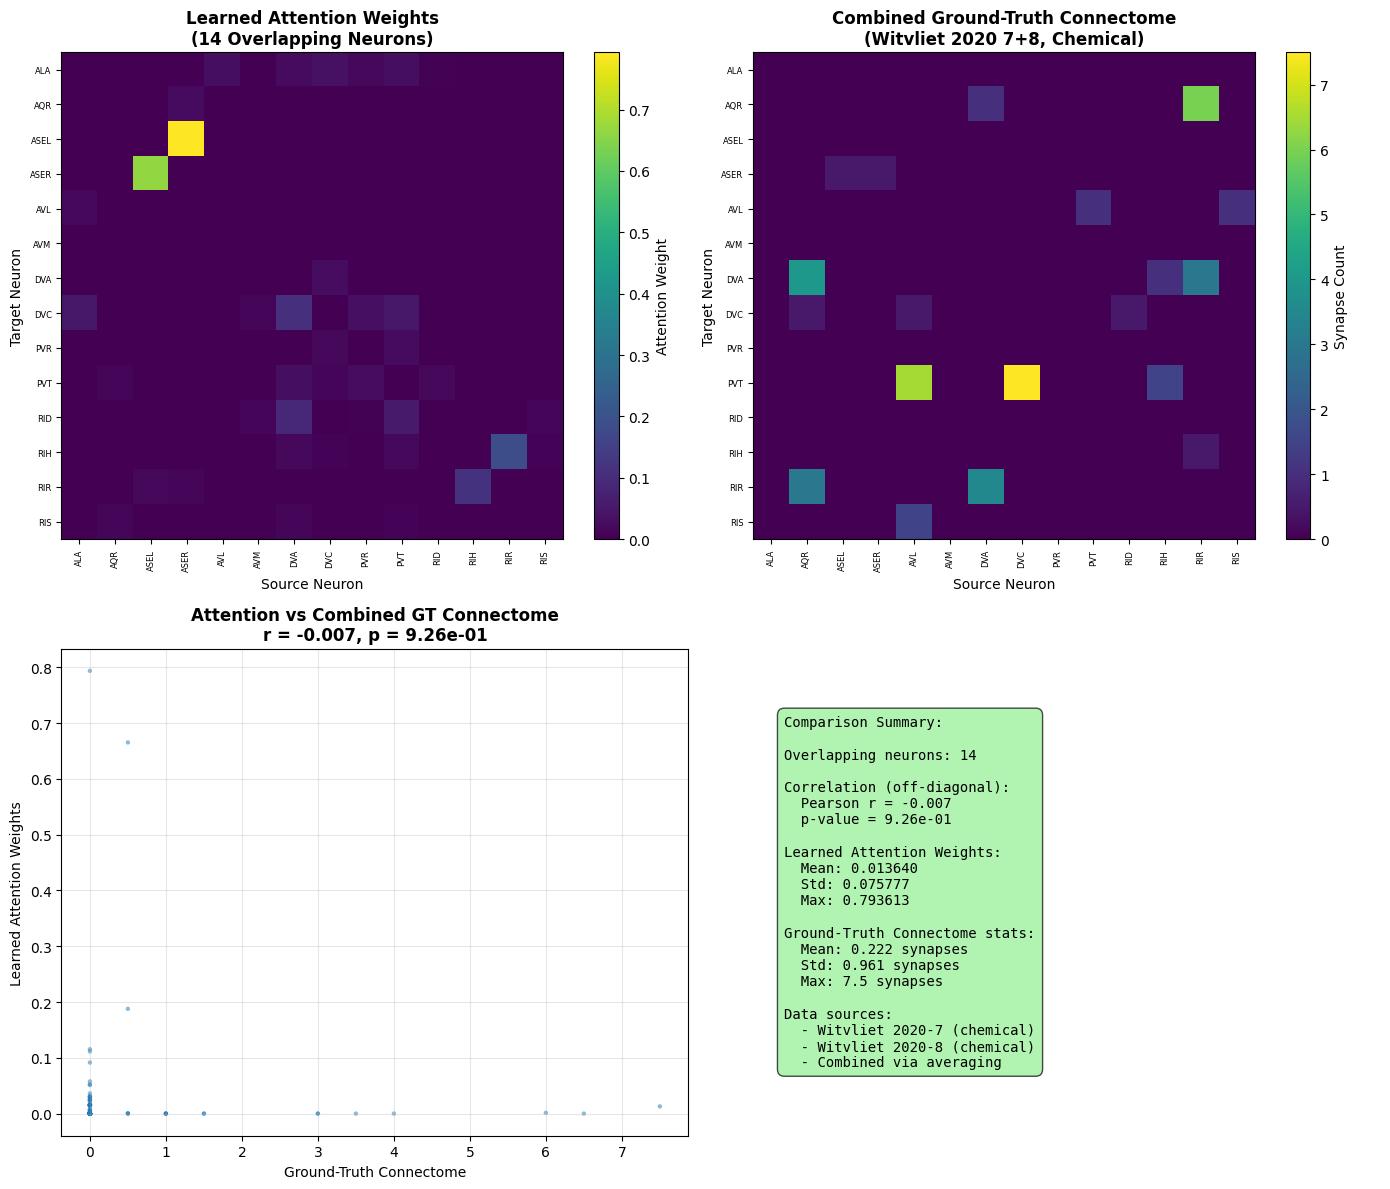


GROUND-TRUTH CONNECTOME CORRELATION ANALYSIS
Attention weights vs Combined Witvliet Connectome (Chemical):
  Pearson r = -0.007
  p-value = 9.26e-01
  Valid data points: 182



In [37]:
# Visualize comparison between learned attention and combined ground-truth connectome
print("Creating comparison visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1) Learned attention matrix (subset)
im1 = axes[0, 0].imshow(attention_submatrix, cmap='viridis', aspect='auto')
axes[0, 0].set_title(f'Learned Attention {attention_type.title()}\n({len(overlap_neurons)} Overlapping Neurons)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Source Neuron')
axes[0, 0].set_ylabel('Target Neuron') # Rows are targets neurons (incoming edges)
axes[0, 0].set_xticks(range(len(overlap_neurons)), overlap_neurons, rotation=90, fontsize=6)
axes[0, 0].set_yticks(range(len(overlap_neurons)), overlap_neurons, fontsize=6)
plt.colorbar(im1, ax=axes[0, 0], label=attention_label)

# 2) Combined ground-truth connectome
im2 = axes[0, 1].imshow(gt_adj_final, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Combined Ground-Truth Connectome\n(Witvliet 2020 7+8, Chemical)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Source Neuron')
axes[0, 1].set_ylabel('Target Neuron') # Columns are source neurons (outgoing edges)
axes[0, 1].set_xticks(range(len(overlap_neurons)), overlap_neurons, rotation=90, fontsize=6)
axes[0, 1].set_yticks(range(len(overlap_neurons)), overlap_neurons, fontsize=6)
plt.colorbar(im2, ax=axes[0, 1], label='Synapse Count')

# 3) Correlation analysis
# Flatten matrices for correlation
attn_flat = attention_submatrix.flatten()
gt_flat = gt_adj_final.flatten()

# Remove diagonal elements for correlation (since attention diagonal is always 0)
mask = ~np.eye(attention_submatrix.shape[0], dtype=bool).flatten()
attn_flat_offdiag = attn_flat[mask]
gt_flat_offdiag = gt_flat[mask]

corr, p_val = pearsonr(attn_flat_offdiag, gt_flat_offdiag)

# Scatter plot
axes[1, 0].scatter(gt_flat_offdiag, attn_flat_offdiag, alpha=0.5, s=10, edgecolors='none')
axes[1, 0].set_xlabel('Ground-Truth Connectome')
axes[1, 0].set_ylabel(f'Learned Attention {attention_type.title()}')
axes[1, 0].set_title(f'Attention vs Combined GT Connectome\nr = {corr:.3f}, p = {p_val:.2e}', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4) Summary statistics
axes[1, 1].axis('off')
summary_text = f"""Comparison Summary:

Overlapping neurons: {len(overlap_neurons)}

Correlation (off-diagonal):
  Pearson r = {corr:.3f}
  p-value = {p_val:.2e}

Learned Attention {attention_type.title()}:
  Mean: {attention_submatrix.mean():.6f}
  Std: {attention_submatrix.std():.6f}
  Max: {attention_submatrix.max():.6f}
  
Ground-Truth Connectome stats:
  Mean: {gt_adj_final.mean():.3f} synapses
  Std: {gt_adj_final.std():.3f} synapses
  Max: {gt_adj_final.max():.1f} synapses

Data sources:
  - Witvliet 2020-7 (chemical)
  - Witvliet 2020-8 (chemical)
  - Combined via averaging"""

axes[1, 1].text(0.05, 0.5, summary_text, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7),
                family='monospace')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"GROUND-TRUTH CONNECTOME CORRELATION ANALYSIS")
print(f"{'='*60}")
print(f"Attention {attention_type} vs Combined Witvliet Connectome (Chemical):")
print(f"  Pearson r = {corr:.3f}")
print(f"  p-value = {p_val:.2e}")
print(f"  Valid data points: {len(attn_flat_offdiag)}")
print(f"{'='*60}\n")

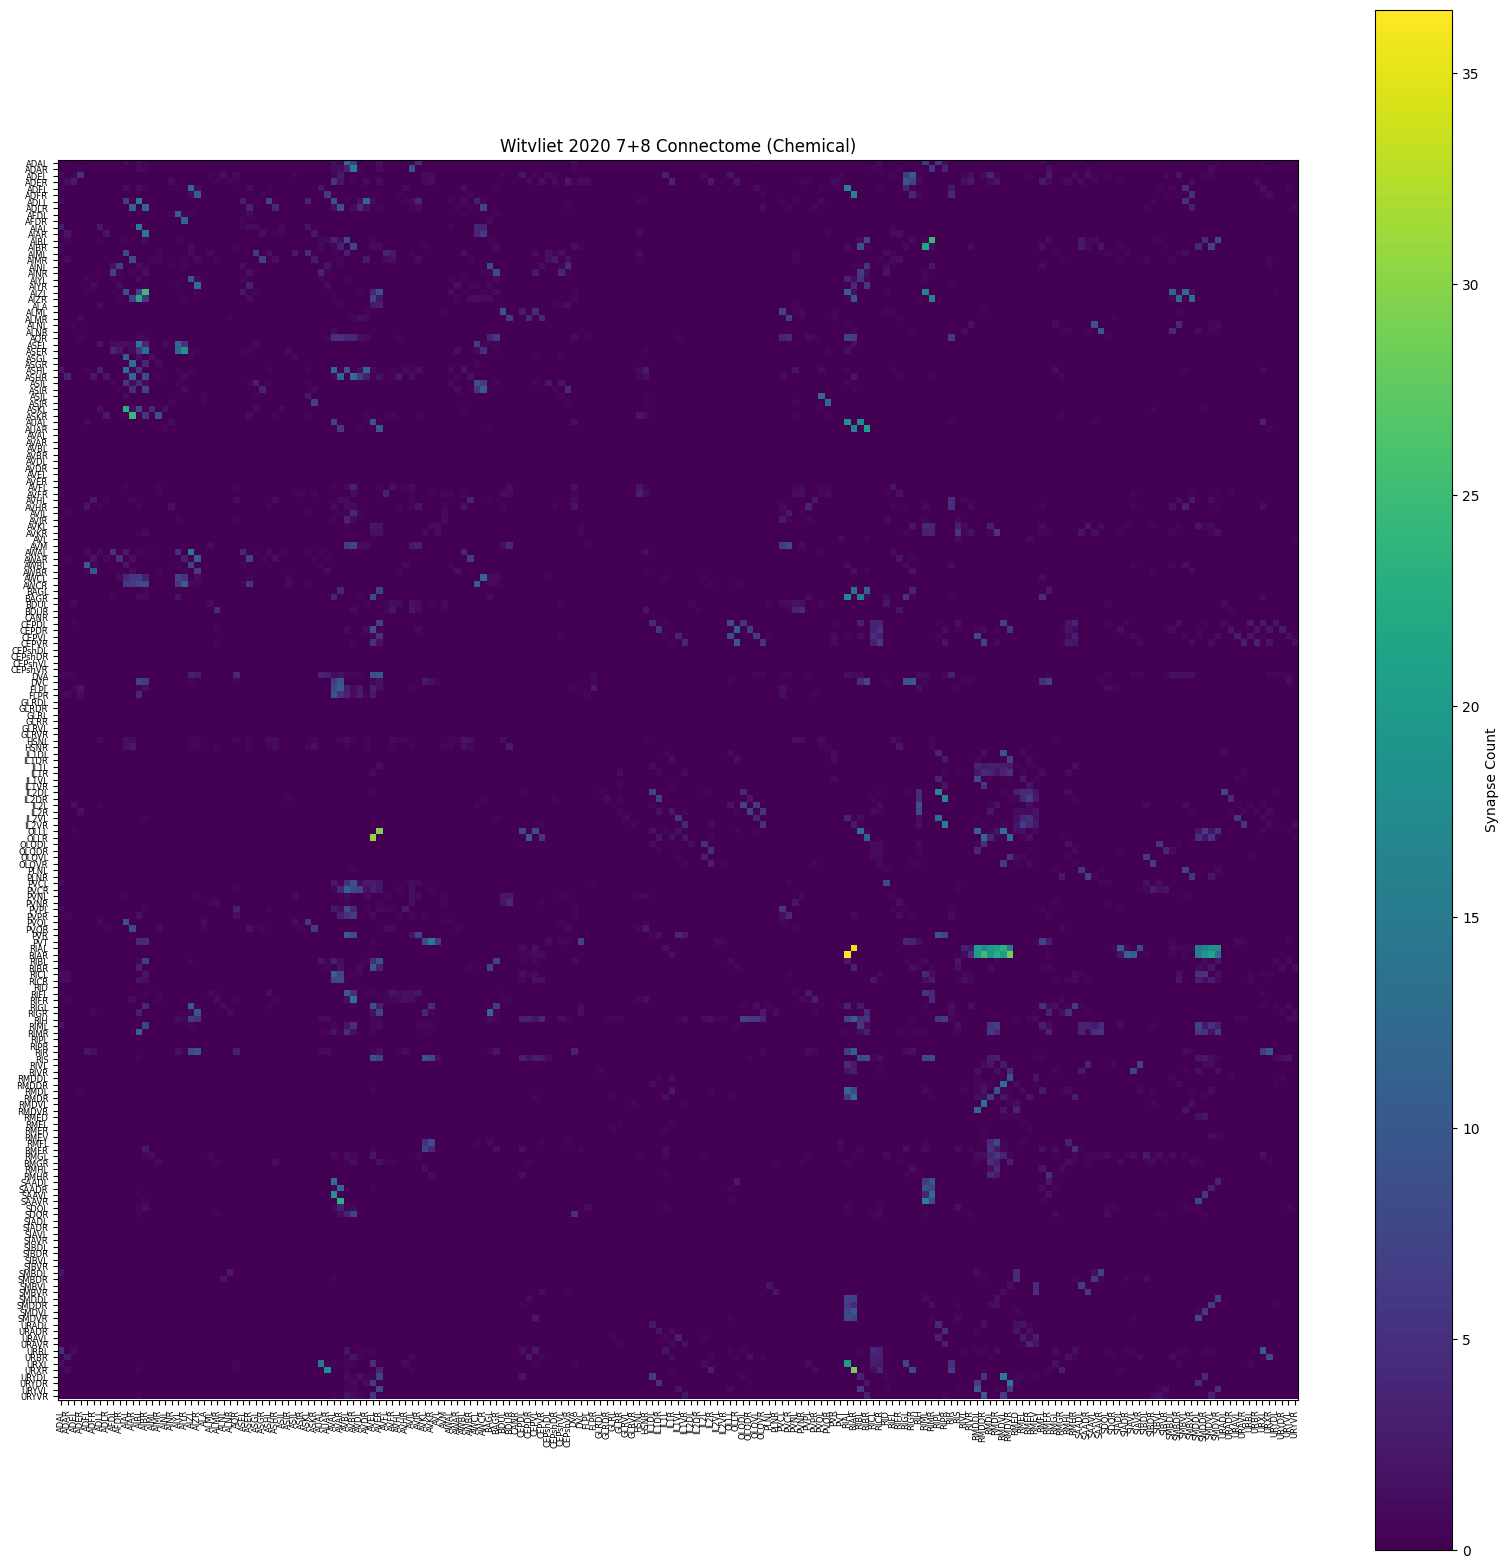

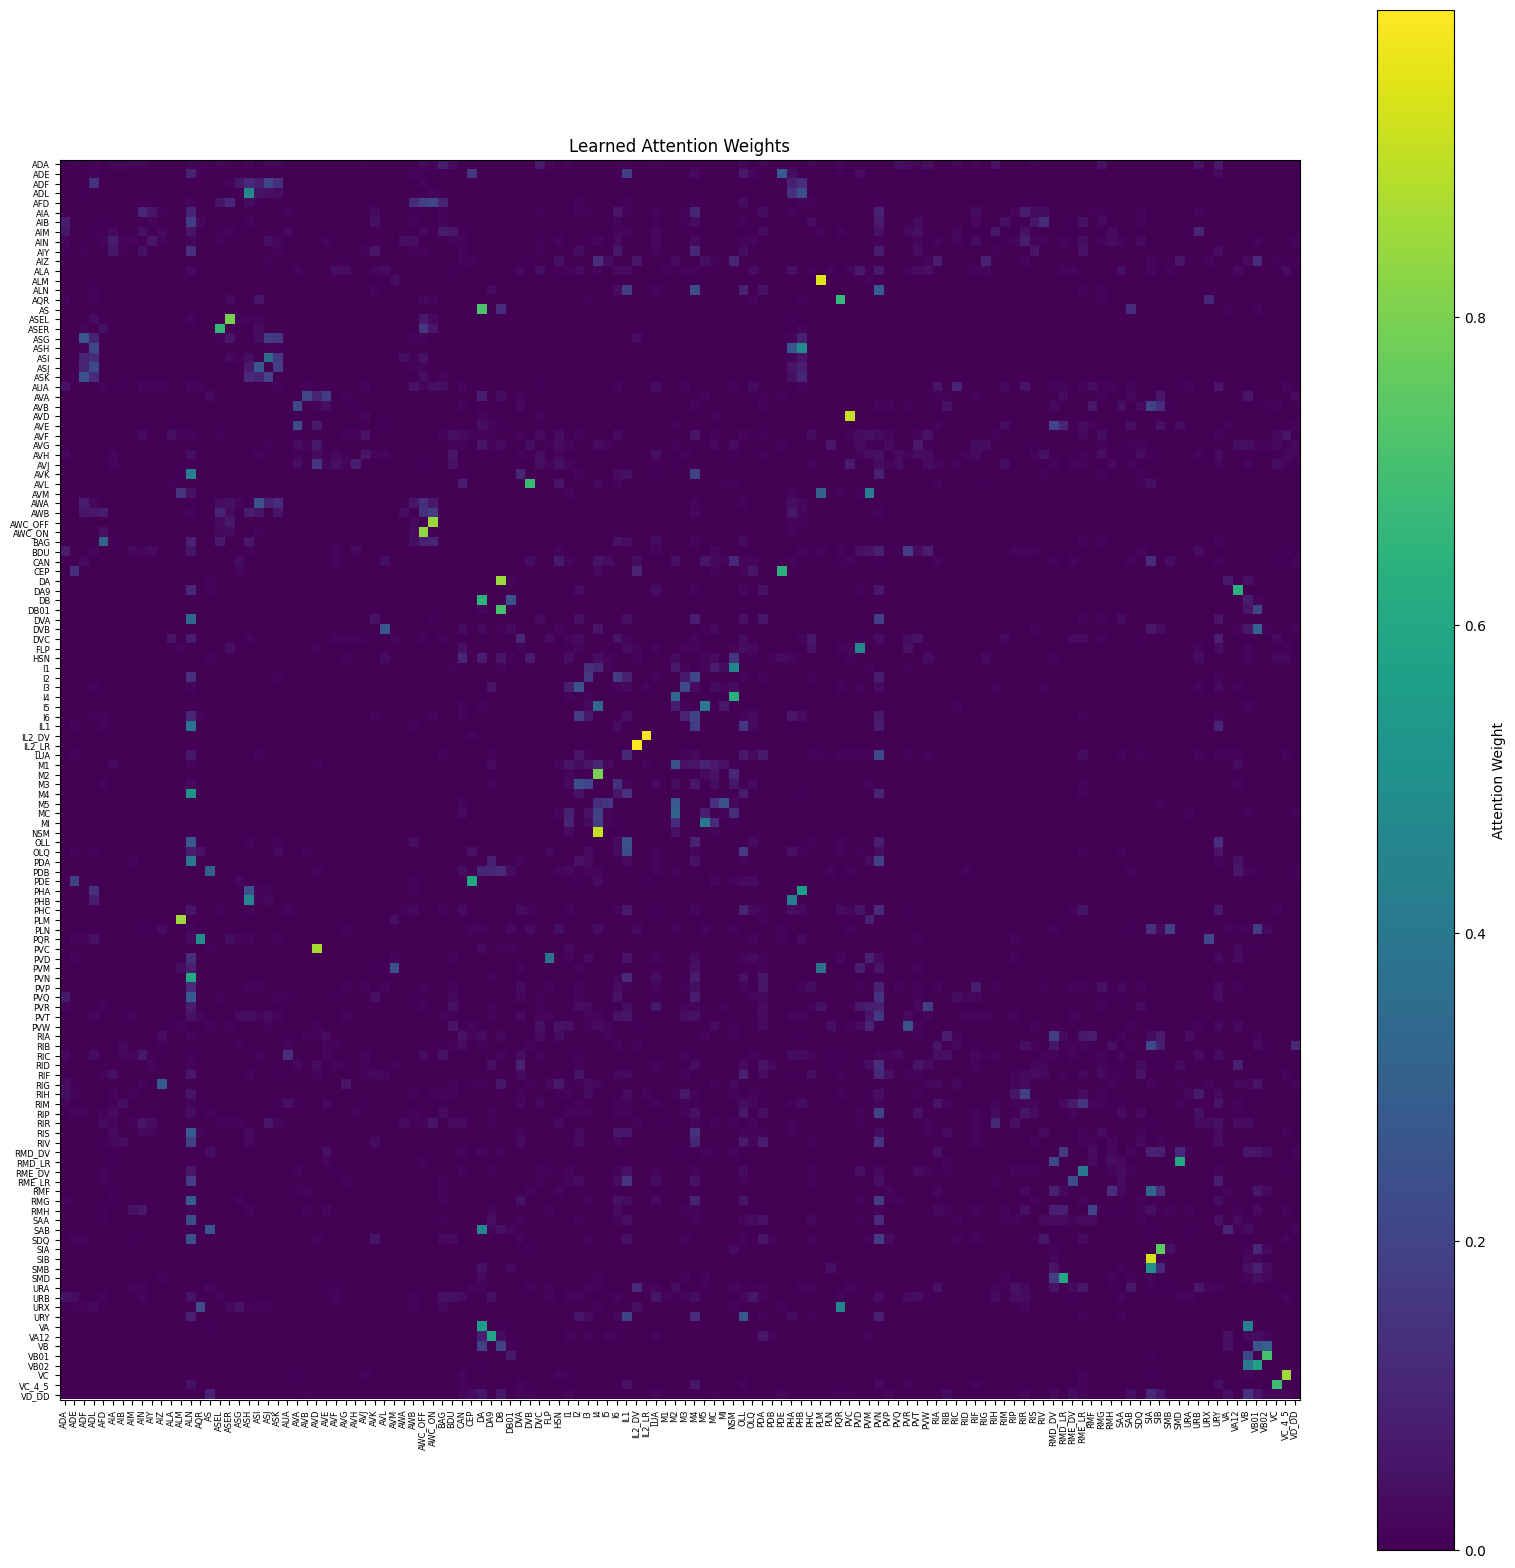

In [39]:
# Full matrices plotted below

# Ground-truth connectome
plt.figure(figsize=(20, 20))
plt.imshow(gt_adj_combined)
# label axes with all_neurons
plt.xticks(range(len(all_neurons)), all_neurons, rotation=90, fontsize=6) # reduce font size
plt.yticks(range(len(all_neurons)), all_neurons, fontsize=6) # reduce font size
plt.colorbar(label='Synapse Count')
plt.title('Witvliet 2020 7+8 Connectome (Chemical)')
plt.show()

# Learned attention weights
plt.figure(figsize=(20, 20))
plt.imshow(attention_weights_matrix)
# label axes with neuron_classes
plt.xticks(range(len(neuron_classes)), neuron_classes, rotation=90, fontsize=6) # reduce font size
plt.yticks(range(len(neuron_classes)), neuron_classes, fontsize=6) # reduce font size
plt.colorbar(label='Attention Weight')
plt.title('Learned Attention Weights')
plt.show()
